# CS 503 Foundation Models: Part 2 - nanoMaskGIT

#### Goals:

The goal of this second part is to familiarize yourself with the following topics:
- Bi-directional attention
- Encoder-only Transformer (e.g. BERT, MaskGIT, ...) models
- Basic masking schemes
- Masked modelling on text and images
- Masked inference

This notebook should give you a solid foundation of working with masked image models.
If you want to know more about these topics, please see some of the reading material in the lectures and at the bottom of this notebook, and feel free to ask the TAs.


#### Instructions:

- Your task is to fill in the missing code in the acompagning codebase (highlighted by `???`), run the training loops and evaluate the trained models with this notebook.
- Submit the notebook with all cells executed, as well as `nanofm/models/maskgit.py`.
- The notebooks are individual homework.

# 1. Setup

Please follow the instructions in the [README.md](../README.md) file to set up the environment.

### 1.1 Imports

In [1]:
# Switch path to root of project
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))

%load_ext autoreload
%autoreload 2

In [2]:
import re
import torch
from einops import rearrange
from transformers import AutoTokenizer
from tokenizers.processors import TemplateProcessing

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

from nanofm.utils.checkpoint import load_model_from_safetensors
from nanofm.data.vision.tokenized_mnist import create_tokenized_mnist_dataloader, detokenize_MNIST

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = True
# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_grad_enabled(False)

/home/tlphan/miniconda3/envs/nanofm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/tlphan/miniconda3/envs/nanofm/lib/python3.10/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


torch.autograd.grad_mode.set_grad_enabled(mode=False)

---

## 2 Training nanoMaskGIT on MNIST for image generation

In this exercise, we will implement a simplified masked generative model, similar to [MaskGIT](https://masked-generative-image-transformer.github.io/). 
As with our nanoGPT implementation, we will train it on MNIST for image generation, but will also later explore using it for text generation on TinyStories!

#### Masked modeling - Training objective

In contrast to autoregressive models that are trained to predict the next token given the context so far, masked generative models like MaskGIT are trained to predict any (masked-out) token given any other (non-masked) subset of tokens.
Consider the following example: 

**Original Sentence:**  
```
"The quick brown fox jumps over the lazy dog."
```

**Masked Training Example (cloze):**  
```
"The quick [MASK] fox jumps over the [MASK] dog."
```

**Goal:**  
The model must predict:
- `[MASK]` → "brown"
- `[MASK]` → "lazy"

By repeatedly training the model to predict these randomly masked tokens across a large dataset, MaskGIT learns how tokens fit contextually within sequences.


#### Masked modeling - Inference


By training a model with randomized masking ratios, we are able to use it to progressively "unmask" a fully masked initial sequence.
At inference, the model starts with all tokens masked and progressively unmasks tokens in multiple steps. Let's show an inference example generating two (`k=2`) tokens at a time.

**Initial Masked Sequence:**  
```
"[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]"
```

**Step-by-step Generation (k=2 tokens at a time):**  

- **Step 1:**  
```
"The [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] dog."
```

- **Step 2:** (unmask next 2 most confident tokens)  
```
"The quick [MASK] [MASK] [MASK] [MASK] [MASK] lazy dog."
```

- **Step 3:** (unmask next 2 tokens)  
```
"The quick [MASK] fox [MASK] [MASK] [MASK] lazy dog."
```

- **Step 4:** (unmask next 2 tokens)  
```
"The quick brown fox jumps [MASK] the lazy dog."
```

- **Step 5 (Final):** (all tokens unmasked)  
```
"The quick brown fox jumps over the lazy dog."
```

At each inference step, MaskGIT predicts all masked-out tokens simultaneously (in parallel), and, based on the predicted probabilites, selects the `k` (here `k=2`) most likely tokens. 
After deciding on which tokens to use, we sample a token index from the predicted probability distribution for each token, and add the tokens to the sequence. 
This, now slightly less masked, sequence is then used as the input for the next round, where again, the `k=2` most confident tokens are chosen of the remaining masked targets.

A crucial difference of masked models to next-token prediction is that at each inference step we can freely choose the number of tokens `k` to simultaneously decode. 
Depending on the choice of `k`, this can speed up inference significantly, at little cost to generation performance. 
For example, see the comparison between raster-scan autoregressive, and masked generation below.
Each frame of the gif is one generation step. Autoregressive generation predicts each token one-by-one, while masked models may predict them in parallel.

![adsf](https://masked-generative-image-transformer.github.io/imgs/sampling.gif)

### 2.1 Overview and tasks

To implement nanoMaskGIT, we ask you to complete the subsections below by directly filling in the missing lines in the code base.

#### 2.1.1 Initialize nanoMaskGIT (5 points)

We will reuse the exact same Transformer layers and trunk built last week for the nanoGPT model, but this time we will use it to assemble a MaskGIT-like model in `nanofm.models.maskgit.MaskGIT`.
It consists of a few operations executed in series. Initialize the following modules in the constructor:
1. The discrete input tokens are embedded with an `nn.Embedding` layer. Initialize `self.input_embedding` accordingly, taking into account the vocabulary size.
2. On top of that, we add learnable positional embeddings. Initialize `self.positional_embedding` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`max_seq_len`, `dim`).
3. To indicate masked-out tokens and provide placeholders to write the targets, initialize `self.mask_token` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`dim`).
4. This then gets passed to a Transformer trunk. Initialize `self.trunk` with the trunk you implemented last week.
5. Finally we project the trunk output through a LayerNorm and output projection that maps the elements from the Transformer dimension to the vocabulary size (as a one-hot vector per token). Initialize `self.out_norm` and `self.to_logits`. The bias term for `self.to_logits` should always be set to False.

#### 2.1.2 Implement the forward function and loss (10 points)

Next, let's implement the `forward_model` function:
1. Pass the input tokens through the embedding. 
2. Given the `mask`, replace these embeddings by the learned `self.mask_token`, wherever `mask == True`.
3. Add the positional embedding, pass it through the Transformer trunk, output normalization, and output projection.
4. When calling the Transformer trunk, no attention mask needs to be specified. This model performs full self-attention between all masked and non-masked tokens.

Finally, we need to compute the cross-entropy loss between the logits and the ground-truth targets. Please complete the `compute_ce_loss` function accordingly, and take into account the ignore_index token. We do not want to compute a loss on non-masked tokens that we pass as input; we only compute it on masked-out tokens that we predict.

#### 2.1.3 Implement random masking (15 points)

As used in the `forward` function, during training we want to randomize the `mask` you just applied to the inputs. 
For that, please complete the `generate_random_mask` function that should return a random mask where True = masked-out and False = not masked.
Each sample in the batch should randomly mask out between 1 and L tokens, where L is the sequence length. 
When L tokens are masked-out, it means there is no input and all tokens are predicted.
When only 1 token is masked-out, it means that all but one token are given as input, and only one is predicted. 
You should be able to see why we have to have at least one token masked.

The returned mask tensor should be of type `torch.BoolTensor`, moved to the same device (GPU) as `seq`, and be of shape (B, L).
Note that both the number of mask tokens, as well as the placement of the masks should be sampled completely uniformly at random, for every sample in the batch individually.
That means you should not apply and broadcast the same mask to the entire batch.

#### 2.1.4 MaskGIT schedule and generation function (20 points)

Now let's implement the generation function. We do that in two steps:

First, let's implement a so-called generation schedule in `get_maskgit_schedule`. 
Its task is to give us a list of number of tokens to unmask at every prediction step. 
It's quite common to make this a cosine schedule, i.e. where the tokens are unmasked slowly at the beginning, then in the middle many tokens are predicted at once, and finally in the end we ramp down again.
Here we will implement a much simpler constant schedule, where the number of unmasked tokens per step is constant.
For example, if total_tokens = 17 and num_steps = 8, then the schedule should be: [2, 2, 2, 2, 2, 2, 2, 3]. 
If the total number of tokens is not divisible by the number of steps, we simply add the remainder to the last step.
The `schedule` should be a list of integers of length `num_steps`, where each integer represents the number of tokens to unmask at that step. 
The sum of the integers in `schedule` should equal `total_tokens`.

With the simple schedule implemented, let's use it in the `generate` function. Generation is performed in a loop in the following steps:
1. Given the sequence and mask so far, simply pass them through the network to get the logits.
2. Then, select the subset of logits that we actually want to predict, i.e. the masked-out tokens.
3. Over all these predicted tokens, we only want to keep the most "confident" predictions. We select for these by computing the maximum logit value for each token as a proxy. The higher the maximum logit is for a given token, the more "confident" it is in its prediction.
4. Now, let's select the top-k tokens according to these confidence scores. You get the number of tokens `k` from the generation schedule.
5. Sample the token indices from these `k` selected token logits. You should use the `sample_tokens` function from `utils/sampling.py`, and remember to pass the relevant sampling hyperparameters.
6. Update the sequence and mask for the next round using the newly sampled tokens and their positions.
7. Repeat until the end of the generation schedule, when the sequence is fully unmasked.

### 2.2 Training the model

We defined a training config for you in: `cfgs/nanoMaskGIT/mnist_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 1xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=1 run_training.py --config cfgs/nanoMaskGIT/mnist_d8w512.yaml
```

This training should be pretty fast and only take a few minutes. Because masked image models are harder to overfit, we increased the number of training steps five-fold, compared to nanoGPT. You should reach a final validation loss below 0.57, and your loss curves should look something like the following:

<img src="./assets/nanoMaskGIT_mnist.png" alt="nanoMaskGIT MNIST loss curves" width="1000">

### 2.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

<img src="./assets/phantuanlinh_maskGIT_mnist.png" alt="nanoMaskGIT MNIST loss curves" width="1000">

### 2.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [3]:
ckpt_path = './outputs/nanoMaskGIT/mnist_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's plot some class-conditional generations! We seed the generation by providing the first token, whose index is equal to the number we'd like to generate.
For that token, we initialize the mask with `False`, i.e. indicating that that token is given as input, i.e. not masked. 
The rest of the tokens are masked, and it does not matter what value they have in the `seq` tensor, as they are overwritten by the learnable mask token in the Transformer.

In [4]:
label = 5

seq = torch.zeros(50, dtype=torch.long, device=device)
mask = torch.ones(50, dtype=torch.bool, device=device)
seq[0] = label
mask[0] = False

output = model.generate(seq, mask, num_steps=8, temp=1.0, top_p=0.9, return_history=False)
output

tensor([[ 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 13, 13, 13, 12, 10, 10, 25,
         24, 18, 10, 10, 10, 10, 22, 21, 12, 10, 10, 10, 10, 10, 15, 20, 10, 10,
         10, 10, 13, 17, 18, 10, 10, 10, 10, 10, 10, 10, 10, 10]])

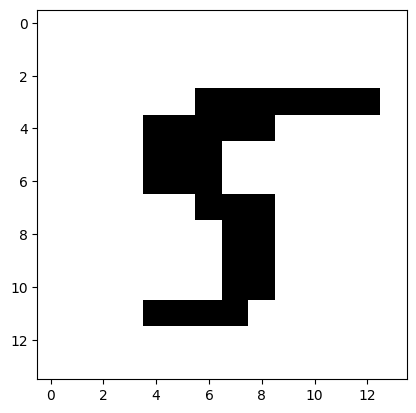

In [5]:
reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
plt.imshow(reconst[0], cmap='gray_r')

<img src="./assets/maskgit_2.4_example_output1.png" alt="nanoMaskGIT example output 1" width="500">

Let's now generate 10 random samples for all 10 classes. Most should look quite reasonable.

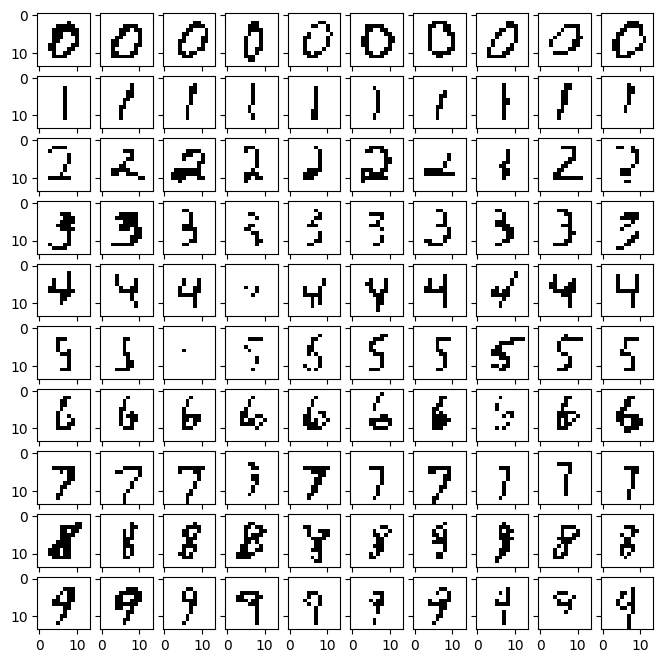

In [6]:
def generate_samples(model, num_steps=8, temp=1.0, top_p=0.0, top_k=0.0, n_samples=10):
    fig = plt.figure(figsize=(8., 8.))
    grid = ImageGrid(fig, 111, nrows_ncols=(10, n_samples), axes_pad=0.1)
    for label in range(10):
        for sample_idx in range(n_samples):
            grid_idx = label * n_samples + sample_idx
            
            seq = torch.zeros(50, dtype=torch.long, device=device)
            mask = torch.ones(50, dtype=torch.bool, device=device)
            seq[0] = label
            mask[0] = False
            output = model.generate(seq, mask, num_steps=num_steps, temp=temp, top_p=top_p, top_k=top_k, return_history=False)
            
            reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
            grid[grid_idx].imshow(reconst[0], cmap='Greys', vmin=0, vmax=1)
    plt.show()
    
generate_samples(model, num_steps=8, temp=0.7, top_p=0.9, top_k=0.0)

<img src="./assets/maskgit_2.4_example_output2.png" alt="nanoMaskGIT example output 1" width="1000">

### 2.5 Open-ended questions (10 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

#### 2.5.1 Intermediate generation steps

`model.generate` has an optional flag `return_history`. Show the intermediate generation steps. What do you observe?

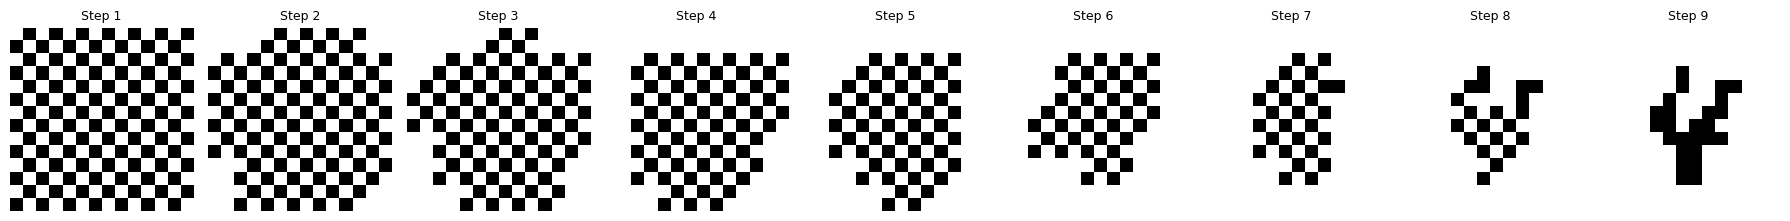

In [30]:
label = 4
num_steps = 8

seq = torch.zeros(50, dtype=torch.long, device=device)
mask = torch.ones(50, dtype=torch.bool, device=device)
seq[0] = label
mask[0] = False

seq_history, mask_history = model.generate(
    seq, mask, num_steps=num_steps, temp=1.0, top_p=0.9, return_history=True
)

num_frames = seq_history.shape[0]

fig, axes = plt.subplots(1, num_frames, figsize=(2 * num_frames, 2.5))
for i in range(num_frames):
    frame_seq = seq_history[i].unsqueeze(0)
    img = detokenize_MNIST(frame_seq, patch_size=2, account_for_labels=True).cpu()
    axes[i].imshow(img[0], cmap='gray_r', vmin=0, vmax=1)
    axes[i].set_title(f"Step {i+1}", fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

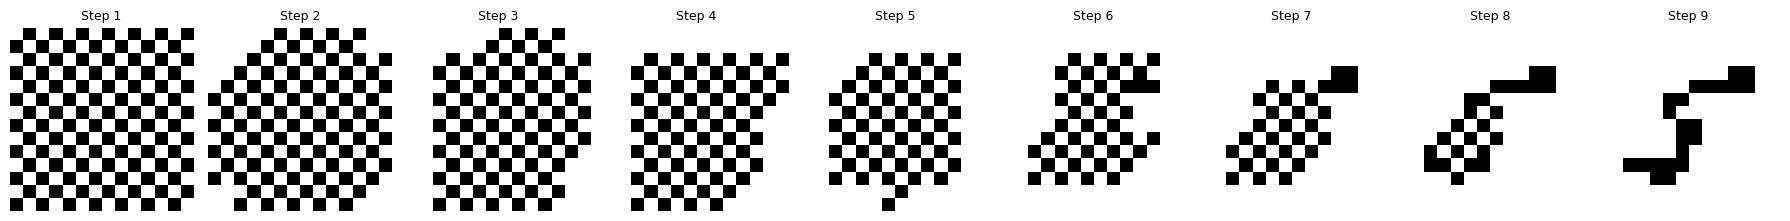

In [31]:
label = 5
num_steps = 8

seq = torch.zeros(50, dtype=torch.long, device=device)
mask = torch.ones(50, dtype=torch.bool, device=device)
seq[0] = label
mask[0] = False

seq_history, mask_history = model.generate(
    seq, mask, num_steps=num_steps, temp=1.0, top_p=0.9, return_history=True
)

num_frames = seq_history.shape[0]

fig, axes = plt.subplots(1, num_frames, figsize=(2 * num_frames, 2.5))
for i in range(num_frames):
    frame_seq = seq_history[i].unsqueeze(0)
    img = detokenize_MNIST(frame_seq, patch_size=2, account_for_labels=True).cpu()
    axes[i].imshow(img[0], cmap='gray_r', vmin=0, vmax=1)
    axes[i].set_title(f"Step {i+1}", fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

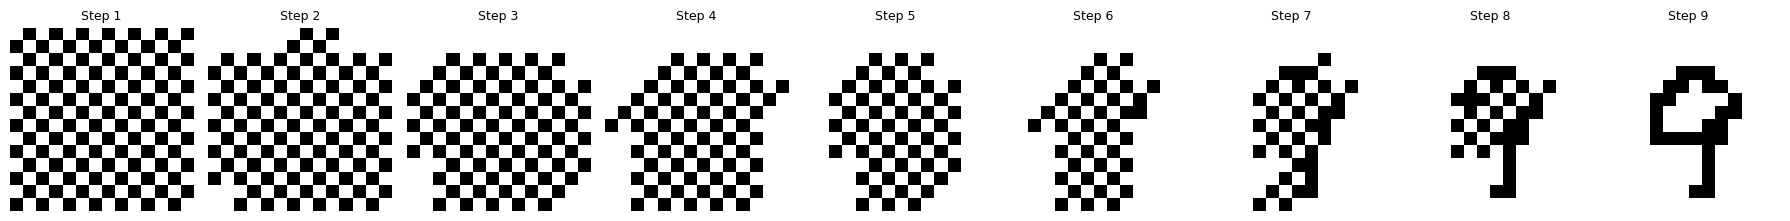

In [34]:
label = 9
num_steps = 8

seq = torch.zeros(50, dtype=torch.long, device=device)
mask = torch.ones(50, dtype=torch.bool, device=device)
seq[0] = label
mask[0] = False

seq_history, mask_history = model.generate(
    seq, mask, num_steps=num_steps, temp=1.0, top_p=0.9, return_history=True
)

num_frames = seq_history.shape[0]

fig, axes = plt.subplots(1, num_frames, figsize=(2 * num_frames, 2.5))
for i in range(num_frames):
    frame_seq = seq_history[i].unsqueeze(0)
    img = detokenize_MNIST(frame_seq, patch_size=2, account_for_labels=True).cpu()
    axes[i].imshow(img[0], cmap='gray_r', vmin=0, vmax=1)
    axes[i].set_title(f"Step {i+1}", fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

**Answer:** 
we start with completely masked out image. at each steps, we have more predictions but the observation is that it tends to go from the background first. This makes sense because given all the training data the background is always white so these are the most confident area for the first few steps of generation. And slowly as we get to the center, each smaller stoke of a digit slowly reveals itself, it seems like it starts with one that is not part of a loop-ish because I think it has less variance in the training data. for example we see the upper part of 4, 5 or the bottom of 9 is generated first

#### 2.5.2 Number of inference steps

With MaskGIT, we can freely choose the number of inference steps `k`. We default to `k=8`, but how does generation with `k` = 1, 4, 8, 16, 32, 49 perform? What do you observe?

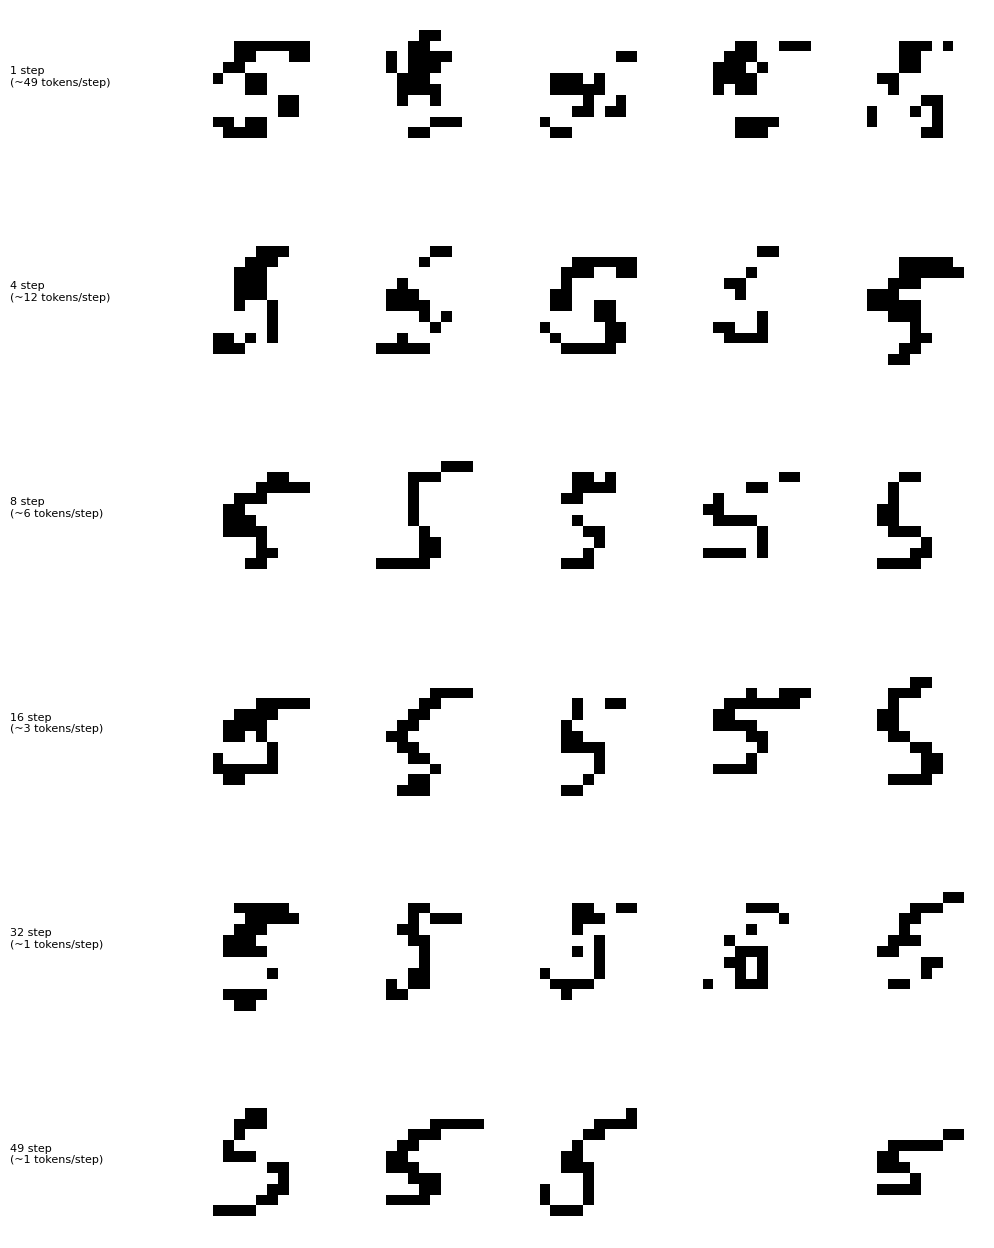

In [46]:
num_steps_list = [1, 4, 8, 16, 32, 49]
n_samples = 5
label = 5

fig, axes = plt.subplots(len(num_steps_list), n_samples, figsize=(2 * n_samples, 2.2 * len(num_steps_list)))

for row, num_steps in enumerate(num_steps_list):
    tokens_per_step = 49 // num_steps
    for col in range(n_samples):
        seq = torch.zeros(50, dtype=torch.long, device=device)
        mask = torch.ones(50, dtype=torch.bool, device=device)
        seq[0] = label
        mask[0] = False

        output = model.generate(seq, mask, num_steps=num_steps, temp=1.0, top_p=0.9, return_history=False)
        img = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
        axes[row, col].imshow(img[0], cmap='gray_r', vmin=0, vmax=1)
        axes[row, col].axis('off')

plt.tight_layout()
plt.subplots_adjust(left=0.18)

# Draw row labels in the left margin after layout is finalized
for row, num_steps in enumerate(num_steps_list):
    tokens_per_step = 49 // num_steps
    ax = axes[row, 0]
    y_fig = (ax.get_position().y0 + ax.get_position().y1) / 2
    fig.text(
        0.01, y_fig,
        f"{num_steps} step\n(~{tokens_per_step} tokens/step)",
        fontsize=8, ha='left'
    )

plt.show()


- k=1: All 49 tokens are predicted at once from a fully masked sequence, with no iterative refinement. The model has no context to condition on beyond the class token, so we got a non readable image. clearly they are not a 5.
- k=4: Significant improvement from k=1. But the quality is still significantly less than where k=8.
- k=16/32 Quality remains high, comparable to 8. More steps means each step places fewer tokens, giving slightly more refinement opportunities, at marginal extra cost.
- k=49 Maximum refinement; every token is placed based on all previously confirmed tokens. However, this does not guarantee a good looking 5 still. it reviews the short comings of our model


---

## 3 Training nanoGPT on TinyStories

Masked generation is quite common for image generation, but has seen a recent resurgence for language models too (e.g. see [LLaDA](https://ml-gsai.github.io/LLaDA-demo/)). 
Let's run a little experiment and train a masked model on TinyStories, just as we did with nanoGPT.

### 3.1 Loading the tokenizer and helper functions

In [47]:
# Load the GPT-2 tokenizer
text_tokenizer = AutoTokenizer.from_pretrained("gpt2", trust_remote_code=True)

# Add padding, start-of-sequence, and end-of-sequence tokens
text_tokenizer.add_special_tokens({'pad_token': '[PAD]'})
text_tokenizer.add_special_tokens({
    'bos_token': '[SOS]',
    'eos_token': '[EOS]',
})
text_tokenizer._tokenizer.post_processor = TemplateProcessing(
    single="[SOS] $A [EOS]",
    special_tokens=[('[EOS]', text_tokenizer.eos_token_id), ('[SOS]', text_tokenizer.bos_token_id)],
)
text_tokenizer

GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[SOS]', 'eos_token': '[EOS]', 'unk_token': '<|endoftext|>', 'pad_token': '[PAD]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50257: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50258: AddedToken("[SOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50259: AddedToken("[EOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [48]:
def token_ids_to_text(token_ids, text_tokenizer):
    """ Helper function to turn token sequences back to well-formatted text. """
    decoded = text_tokenizer.decode(token_ids)
    # Remove [SOS], [EOS], and [PAD] tokens along with surrounding horizontal whitespace only.
    decoded = re.sub(r'[ \t]*\[(SOS|EOS|PAD)\][ \t]*', ' ', decoded)
    # Collapse extra horizontal spaces in each line without touching newline characters.
    decoded = '\n'.join([re.sub(r'[ \t]+', ' ', line).strip() for line in decoded.splitlines()])
    return decoded

### 3.2 Training the model

We defined a training config for you in: `cfgs/nanoMaskGIT/tinystories_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 2xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 run_training.py --config cfgs/nanoMaskGIT/tinystories_d8w512.yaml
```

This training should take over one hour. You should reach a final validation loss around 2.05, and your loss curves should look something like the following:

<img src="./assets/nanoMaskGIT_tinystories.png" alt="nanoMaskGIT TinyStories loss curves" width="1000">

### 3.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

[Note] Your screenshot must clearly show your Weights & Biases (W&B) account (username/entity), usually visible in the top-right corner of the page.

<img src="./assets/phanlinh_maskGIT_tinystories.png" alt="nanoMaskGIT TinyStories loss curves" width="1000">

### 3.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [49]:
ckpt_path = './outputs/nanoMaskGIT/tinystories_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's generate some random (unconditional) stories!

In [50]:
for _ in range(5):
    seq = torch.zeros(256, dtype=torch.long, device=device)
    mask = torch.ones(256, dtype=torch.bool, device=device)
    output = model.generate(seq, mask, num_steps=128, temp=1.0, top_k=100, return_history=False)
    print(token_ids_to_text(output[0], text_tokenizer=text_tokenizer))
    print('\n' + '-'*50 + '\n')

Once upon a time, there was a girl girl called She wanted to be a musician. She, she got on her bike and and took a ride his bike out.
rode around fast and she got a big. She stopped and shouted. â€œCome on, I me!

The man opened his truck and told her girl and said, â€œYou are very smart,â€ He wrapped his back around the park and helped the girl get back.

The girl sat on a bench and listened as the man walked â€œDon was anyone being mean,â€ he smiled. He saw up to her. She smiled wearing its bald and cheeks.

the man said, â€œYou may enjoy it? Come here and stay for bed.â€

little girl waved back and said, â€œYeah, that's a great story. I'm here to miss it so much fun .

--------------------------------------------------

Once upon a time, was a little boy. Tom. Peter was always looking with his. He was carrying at a package of mail.

His Tom in Peter's "What'm you?" he

Tom was: "What will you get?"


Tom:: "An envelope! I's it, I think I need it for you?"


Tom said: "They look yum

<img src="./assets/maskgit_3.4_example_output.png" alt="nanoMaskGIT example output for 3.4" width="1000">

### 3.5 Open-ended questions (10 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

#### 3.5.1 Intermediate generation steps

Similar as in 2.5.1, `model.generate` has an optional flag `return_history`. Show the intermediate generation steps. What do you observe?

In [53]:
num_steps = 16

seq = torch.zeros(256, dtype=torch.long, device=device)
mask = torch.ones(256, dtype=torch.bool, device=device)

seq_history, mask_history = model.generate(
    seq, mask, num_steps=num_steps, temp=1.0, top_k=100, return_history=True
)
# seq_history: (num_steps+1, 256) — step 0 is the initial fully-masked state
print(f"seq_history shape: {seq_history.shape}")

# Pick a few representative snapshots to print
snapshot_steps = [0, 2, 4, 8, 12, num_steps]

MASK_TOKEN_ID = text_tokenizer.pad_token_id  # masked positions still hold 0 in seq_history

for step_idx in snapshot_steps:
    seq_snap = seq_history[step_idx]       # (256,)
    mask_snap = mask_history[step_idx]     # (256,) True = still masked
    num_unmasked = (~mask_snap).sum().item()

    # Replace still-masked positions with [MASK] for display
    display_ids = seq_snap.clone()
    display_ids[mask_snap] = text_tokenizer.mask_token_id if text_tokenizer.mask_token_id is not None else 0

    # Decode only the unmasked tokens to readable text; keep [MASK] placeholders
    tokens = [
        text_tokenizer.decode([tid.item()]) if not mask_snap[i] else '[MASK]'
        for i, tid in enumerate(seq_snap)
    ]
    text_preview = ' '.join(tokens)
    # Trim to a readable length
    text_preview = text_preview[:400] + ('...' if len(text_preview) > 400 else '')

    print(f"{'─'*60}")
    print(f"Step {step_idx:>3d} / {num_steps}  |  tokens placed: {num_unmasked} / 256")
    print(f"{'─'*60}")
    print(text_preview)
    print()


seq_history shape: torch.Size([17, 256])
────────────────────────────────────────────────────────────
Step   0 / 16  |  tokens placed: 0 / 256
────────────────────────────────────────────────────────────
[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [...

────────────────────────────────────────────────────────────
Step   2 / 16  |  tokens placed: 32 / 256
────────────────────────────────────────────────────────────
Once  upon  a  time ,  there  of  the  forest ,  there  little  family [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [M

**Observation**:
in the first few generation, we almost always end of with the most common openning in stories - "Once upon a tine" - Followed by also another common pattern - "There are/ there is something in the forest".  After that, we can see the model subsequently fill up the remaining scatterly with common nouns in a story. and towards the end, it has to fill up the rest with these conditioned nouns bounded a round masked tokens, it generated text with very poor coherence. we almost can see that it tries to add sentence punctations but unfortunately we still end up with incohesive text. 

#### 3.5.2 Number of inference steps

Similar as in 2.5.1, with MaskGIT, we can freely choose the number of inference steps `k`. We default to `k=128`, but how does generation with `k` = 1, 16, 32, 64, 128, 256 perform? What do you observe?

In [54]:
num_steps_list = [1, 16, 32, 64, 128, 256]

for num_steps in num_steps_list:
    seq = torch.zeros(256, dtype=torch.long, device=device)
    mask = torch.ones(256, dtype=torch.bool, device=device)
    output = model.generate(seq, mask, num_steps=num_steps, temp=1.0, top_k=100, return_history=False)
    text = token_ids_to_text(output[0], text_tokenizer=text_tokenizer)
    print(f"{'═'*60}")
    print(f"num_steps = {num_steps}  (~{256 // num_steps} tokens decoded per step)")
    print(text[:500] + ('...' if len(text) > 500 else ''))
    print()


════════════════════════════════════════════════════════════
num_steps = 1  (~256 tokens decoded per step)
════════════════════════════════════════════════════════════
Once upon a time there was for a friends friends He outside.. to had play years the,. to One They., One They and and, day The he the something., to decided, It a. see was it a and day
the and her. came. a could

her and a Tom He She it's He big. it outThe but
He play of, is it. to to mom not. the looked a.
They him,. looked away
. of.'t. the
he some I and had He.
The to the She the the was
,. sad and, ". the
, a mom away the!" the She is Tim and It happy. the that
!" to "!" smiled, day and was w...

════════════════════════════════════════════════════════════
num_steps = 16  (~16 tokens decoded per step)
════════════════════════════════════════════════════════════
Oneily was a, there was a happy of. who name She liked loved. and to her friends bear One fun, or played liked, every day. and to.. She
to wanted saw and they 

k=1: generating all at once is the last thing we want to do. with all the text filled up with common patterns like "once upon time" "there was" and so many traces of common symbols like ", ? !. the quality of generation is unsurprisingly bad here

k=16-64. we can slowly see better local structures and correct grammar for short sentences. However, trace of weird tokens can still be found sometimes.

k=128: Grammarly it makes sense, but does not have much meanings to it.

k=256: Because it generates one token at a time, we can see significant improvement in coherence of the stories. it has a centered character and activities. model stops adding common but out of context to the story. and grammarly it is correct.

#### 3.5.3 Comparison to autoregressive generation

How would you compare these results to the ones you got from nanoGPT? What are some failure modes you observe? And what could be some benefits? Do you have any thoughs on how we can improve text generation with masked models, or should we just stick to autoregressive models?

**Comparison to nanoGPT (autoregressive generation)**

**Quality vs. nanoGPT:**
Because nanoGPT generates text strictly left-to-right, we inherit a strong inductive bias for language. Even at a small scale, nanoGPT produces stories with a clear narrative flow. nanoMaskGIT at low step counts (k=1–64) struggles to match this: grammar may be locally correct but the story lacks global coherence or a centered plot. Only at k=256, which means one token per step, resembling autoregressive order but but not strictly from left to righ, does nanoMaskGIT approach comparable story coherence. Stories had a centered character and activities, and correct grammar.

**Failure modes of nanoMaskGIT:**
- **Global incoherence at low steps:** At k=1–16, the model places all tokens with no mutual context. The result has correct-looking short phrases scattered throughout but no meaningful throughline.
- **Out-of-context tokens:** Even at moderate steps (k=16–64), we observed occasional tokens that are grammatically plausible but in general, disconnected. because a token was committed early based on local confidence before the surrounding narrative was generated.

**Benefits of nanoMaskGIT:**
- **Parallel decoding:** The biggest advantage is that at k=16 we decode 16 tokens per step instead of 1, giving a ~16x inference speedup
- **Bidirectional context:** During training, every token can attend to all others. This makes the model potentially better at tasks requiring global context (for example, filling in a blank in the middle of a sentence), whhile nanoGPT can only attend backwards.

**How to improve masked text generation:**
- **Cosine/non-uniform schedule:** as explained in the original MaskGIT paper, insstead of a constant schedule, unmask fewer tokens in the first and last steps in which uncertainty is highest and more in the middle.
- **More inference steps:** As we observed, k=256  already closes most of the gap with nanoGPT. so if we can use ~128 steps should approximate this quality at half the cost.
- **Better training masking curriculum:** Randomly masking 1–L tokens uniformly means the model rarely sees nearly-complete sequences during training. one way to improve is to introduce curriculum masking, allowing the model to have more chance to look at more context-full training data befre it has to deal with something hard

**Should we stick to autoregressive?**
For pure text generation at small scale, nanoGPT is clearly stronger out of the box. But the inference speed advantage of masked models is real and important at production scale, and the bidirectional context is genuinely useful for non-generative tasks. The right choice depends on the use case. Masked models are not a replacement for autoregressive ones, but a complementary paradigm with different tradeoffs.


## 4 Further reading

Here is some further reading material should you want to dive deeper on masked modeling.

Masked image generation:
- [MaskGIT: Masked Generative Image Transformer](https://arxiv.org/abs/2202.04200)
- [Muse: Text-To-Image Generation via Masked Generative Transformers](https://arxiv.org/abs/2301.00704)
- [MAGE: MAsked Generative Encoder to Unify Representation Learning and Image Synthesis](https://arxiv.org/abs/2211.09117)
- [Randomized Autoregressive Visual Generation](https://arxiv.org/abs/2411.00776)
- [RandAR: Decoder-only Autoregressive Visual Generation in Random Orders](https://arxiv.org/abs/2412.01827)
- [Autoregressive Image Generation without Vector Quantization](https://arxiv.org/abs/2406.11838)
- [4M: Massively Multimodal Masked Modeling](https://arxiv.org/abs/2312.06647)

Masked text generation:
- [Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer](https://arxiv.org/abs/1910.10683)
- [Structured Denoising Diffusion Models in Discrete State-Spaces](https://arxiv.org/abs/2107.03006)
- [Large Language Diffusion Models](https://arxiv.org/abs/2502.09992)

Masked pre-training:
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805)
- [RoBERTa: A Robustly Optimized BERT Pretraining Approach](https://arxiv.org/abs/1907.11692)
- [ELECTRA: Pre-training Text Encoders as Discriminators Rather Than Generators](https://arxiv.org/abs/2003.10555)
- [Masked Autoencoders Are Scalable Vision Learners](https://arxiv.org/abs/2111.06377)
- [BEiT: BERT Pre-Training of Image Transformers](https://arxiv.org/abs/2106.08254)
- [BEiT v2: Masked Image Modeling with Vector-Quantized Visual Tokenizers](https://arxiv.org/abs/2208.06366)